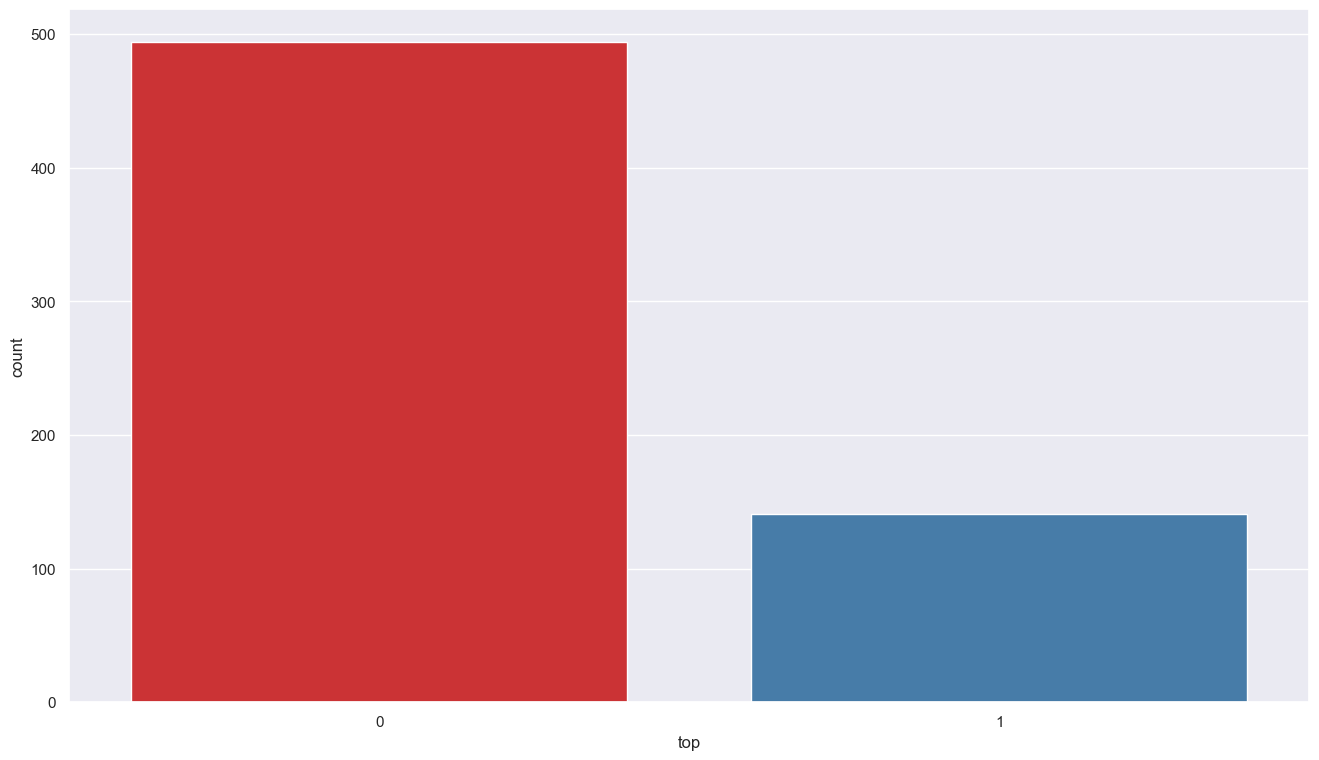

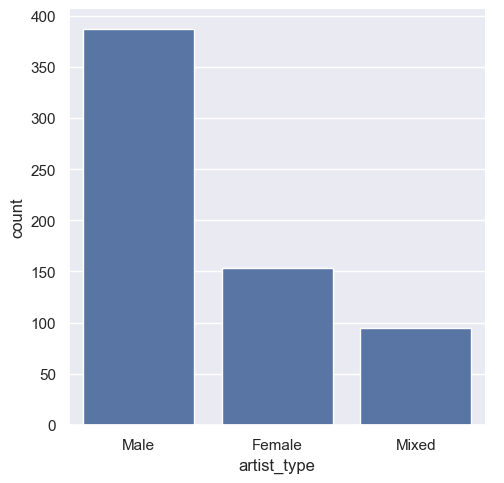

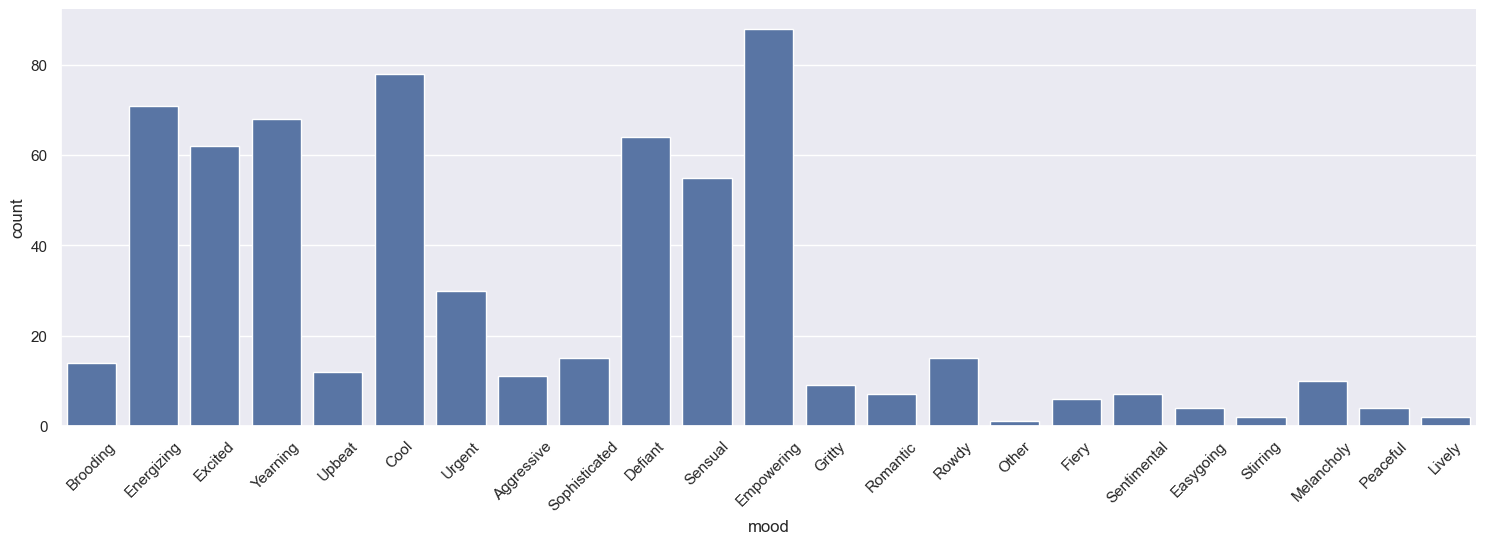

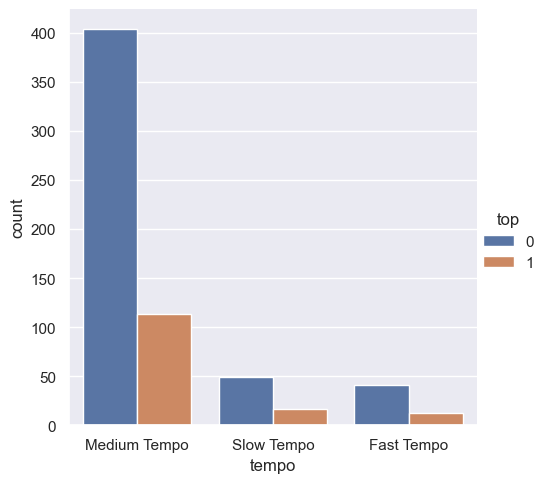

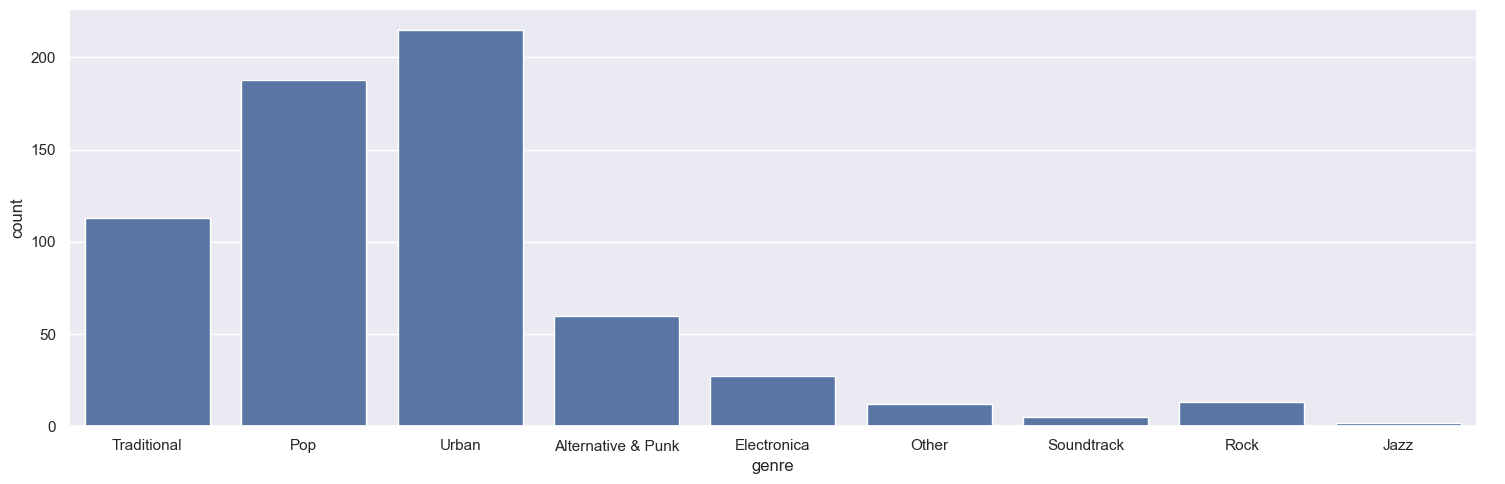

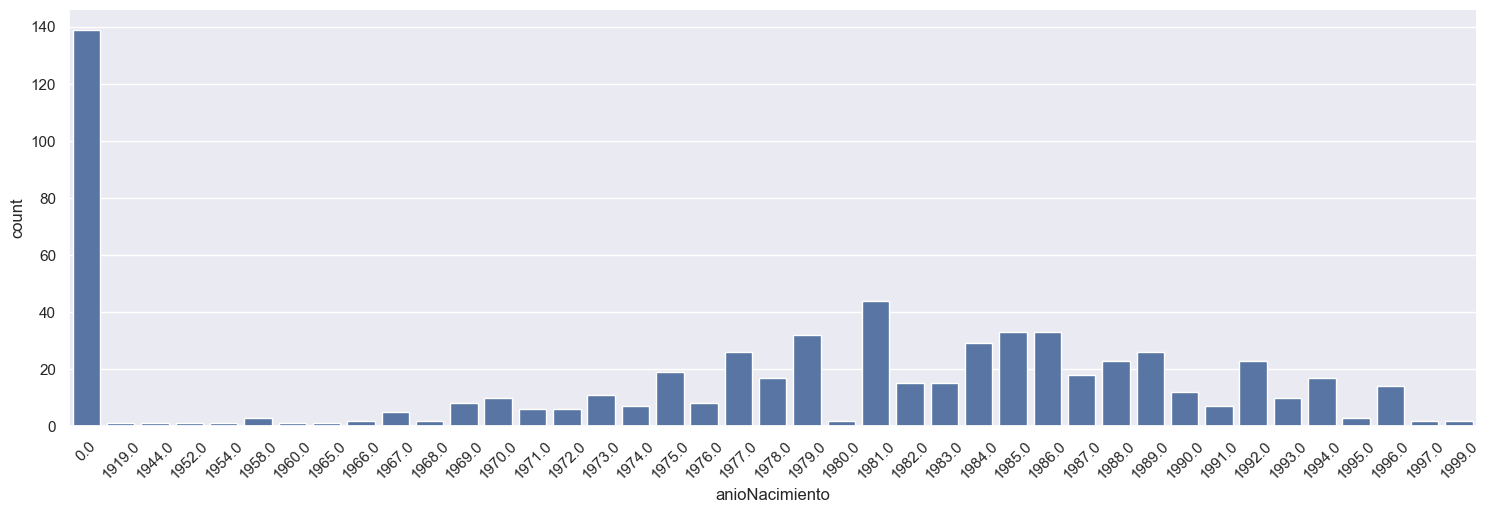

635 635 2


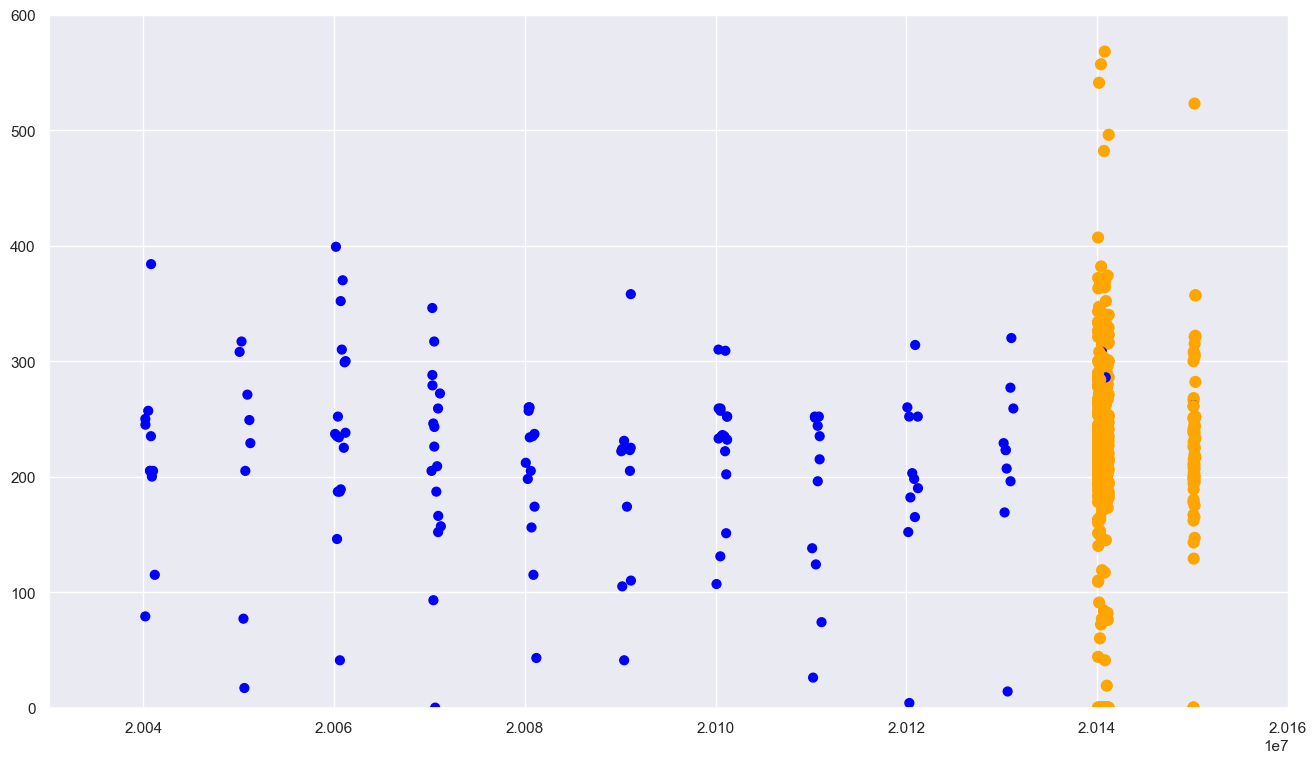

Edad Promedio: 30.10282258064516
Desvió Std Edad: 8.40078832861513
Intervalo para asignar edad aleatoria: 21 a 38
Edad Promedio: 29.862992125984253
Desvió Std Edad: 7.720581726803581
Intervalo para asignar edad aleatoria: 22 a 37


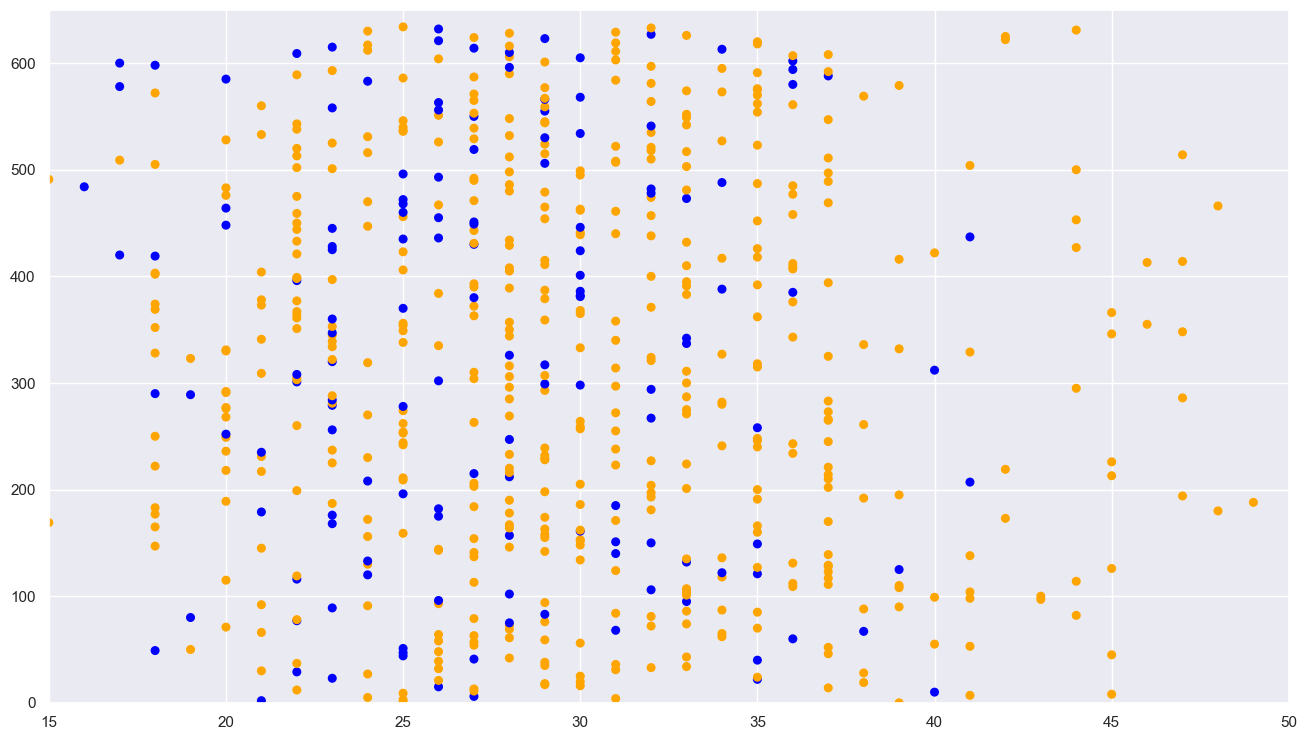

### 🎵 Mood vs Top

moodEncoded       top          
                   mean count sum
0           0  0.000000     1   0
1           1  0.000000     8   0
2           2  0.274194    62  17
3           3  0.145631   103  15
4           4  0.136986   146  20
5           5  0.294872   156  46
6           6  0.270440   159  43

### 👩‍🎤 Artist Type vs Top

artist_typeEncoded       top          
                          mean count sum
0                  1  0.305263    95  29
1                  2  0.320261   153  49
2                  3  0.162791   387  63

### 🎧 Genre vs Top

...

durationEncoded       top          
                       mean count sum
0             0.0  0.295775    71  21
1             1.0  0.333333    30  10
2             2.0  0.212963   108  23
3             3.0  0.202381   168  34
4             4.0  0.232143   112  26
5             5.0  0.145455    55   8
6             6.0  0.208791    91  19

### 👶 Edad vs Top

edadEncoded       top          
                   mean count sum
0         0.0  0.257576    66  17
1         1.0  0.335616   146  49
2         2.0  0.228395   162  37
3         3.0  0.168224   214  36
4         4.0  0.042553    47   2

 Max Depth  Average Accuracy
         1          0.556101
         2          0.556126
         3          0.564038
         4          0.647272
         5          0.614335
         6          0.647173
         7          0.655109
64.88
Predicción: 1
Probabilidad de Acierto: 73.98%
Predicción: No llegó al Top 1
Probabilidad de acierto: 88.89%
Probabilidades completas → No Top: 88.89%, Top: 11.11%


'camino_havana_believer.pdf'

In [1]:
# Imports needed for the script
import numpy as np
import pandas as pd
import seaborn as sb
import re
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from graphviz import Source
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown # instalar 

#agregar la linea que lee el archivo
artists_billboard = pd.read_csv("./artists_billboard.csv")
artists_billboard.shape
artists_billboard.head()
artists_billboard.groupby('top').size()

sb.set_theme(style="darkgrid")
#sb.countplot(data=artists_billboard, x="top", palette="Set1")# esta línea genera un warning se puede cambiar por:
sb.countplot(data=artists_billboard, x="top", hue="top", palette="Set1", legend=False)
#sb.factorplot('artist_type',data=artists_billboard,kind="count") esta línea se borra y se cambia por:
sb.catplot(x='artist_type', data=artists_billboard, kind="count")
#igual la línea siguiente se cambia 
#sb.catplot('mood',data=artists_billboard,kind="count", aspect=3)
sb.catplot(x='mood', data=artists_billboard, kind="count", aspect=3)
#agregar las siguientes líneas
plt.xticks(rotation=45)  # Opcional: rotar etiquetas si son muchas
plt.show()
#la siguente línea se cambia
sb.catplot(x='tempo',data=artists_billboard,hue='top',kind="count")
sb.catplot(x='genre',data=artists_billboard,kind="count", aspect=3)
sb.catplot(x='anioNacimiento',data=artists_billboard,kind="count", aspect=3)
plt.xticks(rotation=45)  # Opcional: rotar etiquetas si son muchas
plt.show()

f1 = artists_billboard['chart_date'].values
f2 = artists_billboard['durationSeg'].values

colores=['orange','blue'] # si no estaban declarados previamente
tamanios=[60,40] # si no estaban declarados previamente
print(len(f1), len(f2), len(tamanios))
asignar=[]
asignar2=[]
for index, row in artists_billboard.iterrows():    
    asignar.append(colores[row['top']])
    asignar2.append(tamanios[row['top']])
    
f1 = artists_billboard['chart_date'].values
f2 = artists_billboard['durationSeg'].values
 
colores=['orange','blue'] # si no estaban declarados previamente
tamanios=[60,40] # si no estaban declarados previamente
 
asignar=[]
asignar2=[]
for index, row in artists_billboard.iterrows():    
    asignar.append(colores[row['top']])
    asignar2.append(tamanios[row['top']])
 
#plt.scatter(f1, f2, c=asignar, s=tamanios) esta línea se cambia
plt.scatter(f1, f2, c=asignar, s=asignar2)
plt.axis([20030101,20160101,0,600])
plt.show()

def edad_fix(anio):
    if anio==0:
        return None
    return anio

artists_billboard['anioNacimiento']=artists_billboard.apply(lambda x: edad_fix(x['anioNacimiento']), axis=1);

def calcula_edad(anio,cuando):
    cad = str(cuando)
    momento = cad[:4]
    if anio==0.0:
        return None
    return int(momento) - anio

artists_billboard['edad_en_billboard']=artists_billboard.apply(lambda x: calcula_edad(x['anioNacimiento'],x['chart_date']), axis=1);

age_avg = artists_billboard['edad_en_billboard'].mean()
age_std = artists_billboard['edad_en_billboard'].std()
age_null_count = artists_billboard['edad_en_billboard'].isnull().sum()
age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)

conValoresNulos = np.isnan(artists_billboard['edad_en_billboard'])

artists_billboard.loc[np.isnan(artists_billboard['edad_en_billboard']), 'edad_en_billboard'] = age_null_random_list
artists_billboard['edad_en_billboard'] = artists_billboard['edad_en_billboard'].astype(int)
print("Edad Promedio: " + str(age_avg))
print("Desvió Std Edad: " + str(age_std))
print("Intervalo para asignar edad aleatoria: " + str(int(age_avg - age_std)) + " a " + str(int(age_avg + age_std)))

age_avg = artists_billboard['edad_en_billboard'].mean()
age_std = artists_billboard['edad_en_billboard'].std()
age_null_count = artists_billboard['edad_en_billboard'].isnull().sum()
age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)

conValoresNulos = np.isnan(artists_billboard['edad_en_billboard'])

artists_billboard.loc[np.isnan(artists_billboard['edad_en_billboard']), 'edad_en_billboard'] = age_null_random_list
artists_billboard['edad_en_billboard'] = artists_billboard['edad_en_billboard'].astype(int)
print("Edad Promedio: " + str(age_avg))
print("Desvió Std Edad: " + str(age_std))
print("Intervalo para asignar edad aleatoria: " + str(int(age_avg - age_std)) + " a " + str(int(age_avg + age_std)))

f1 = artists_billboard['edad_en_billboard'].values
f2 = artists_billboard.index

colores = ['orange','blue','green']

asignar=[]

for index, row in artists_billboard.iterrows():    
    if (conValoresNulos[index]):
        asignar.append(colores[2]) # verde
    else:
        asignar.append(colores[row['top']])

plt.scatter(f1, f2, c=asignar, s=30)
plt.axis([15,50,0,650])
plt.show()

# Mood Mapping 
artists_billboard['moodEncoded'] = artists_billboard['mood'].map( {'Energizing': 6, 
                                        'Empowering': 6,
                                        'Cool': 5, 
                                        'Yearning': 4, # anhelo, deseo, ansia
                                        'Excited': 5, #emocionado
                                        'Defiant': 3, 
                                        'Sensual': 2, 
                                        'Gritty': 3, #coraje 
                                        'Sophisticated': 4,
                                        'Aggressive': 4, # provocativo
                                        'Fiery': 4, #caracter fuerte
                                        'Urgent': 3, 
                                        'Rowdy': 4, #ruidoso alboroto   
                                        'Sentimental': 4,
                                        'Easygoing': 1, # sencillo
                                        'Melancholy': 4, 
                                        'Romantic': 2, 
                                        'Peaceful': 1, 
                                        'Brooding': 4, # melancolico
                                        'Upbeat': 5, #optimista alegre
                                        'Stirring': 5, #emocionante
                                        'Lively': 5, #animado
                                        'Other': 0,'':0} ).astype(int)
# Tempo Mapping 
artists_billboard['tempoEncoded'] = artists_billboard['tempo'].map( {'Fast Tempo': 0, 'Medium Tempo': 2, 'Slow Tempo': 1, '': 0} ).astype(int)
# Genre Mapping 
artists_billboard['genreEncoded'] = artists_billboard['genre'].map( {'Urban': 4, 
                                          'Pop': 3, 
                                          'Traditional': 2, 
                                          'Alternative & Punk': 1,
                                         'Electronica': 1, 
                                          'Rock': 1, 
                                          'Soundtrack': 0, 
                                          'Jazz': 0,
                                          'Other':0,'':0} 
                                       ).astype(int)
# artist_type Mapping 
artists_billboard['artist_typeEncoded'] = artists_billboard['artist_type'].map( {'Female': 2, 'Male': 3, 'Mixed': 1, '': 0} ).astype(int)


# Mapping edad en la que llegaron al billboard
artists_billboard.loc[ artists_billboard['edad_en_billboard'] <= 21, 'edadEncoded']                         = 0
artists_billboard.loc[(artists_billboard['edad_en_billboard'] > 21) & (artists_billboard['edad_en_billboard'] <= 26), 'edadEncoded'] = 1
artists_billboard.loc[(artists_billboard['edad_en_billboard'] > 26) & (artists_billboard['edad_en_billboard'] <= 30), 'edadEncoded'] = 2
artists_billboard.loc[(artists_billboard['edad_en_billboard'] > 30) & (artists_billboard['edad_en_billboard'] <= 40), 'edadEncoded'] = 3
artists_billboard.loc[ artists_billboard['edad_en_billboard'] > 40, 'edadEncoded'] = 4

# Mapping Song Duration
artists_billboard.loc[ artists_billboard['durationSeg'] <= 150, 'durationEncoded']                          = 0
artists_billboard.loc[(artists_billboard['durationSeg'] > 150) & (artists_billboard['durationSeg'] <= 180), 'durationEncoded'] = 1
artists_billboard.loc[(artists_billboard['durationSeg'] > 180) & (artists_billboard['durationSeg'] <= 210), 'durationEncoded'] = 2
artists_billboard.loc[(artists_billboard['durationSeg'] > 210) & (artists_billboard['durationSeg'] <= 240), 'durationEncoded'] = 3
artists_billboard.loc[(artists_billboard['durationSeg'] > 240) & (artists_billboard['durationSeg'] <= 270), 'durationEncoded'] = 4
artists_billboard.loc[(artists_billboard['durationSeg'] > 270) & (artists_billboard['durationSeg'] <= 300), 'durationEncoded'] = 5
artists_billboard.loc[ artists_billboard['durationSeg'] > 300, 'durationEncoded'] = 6

drop_elements = ['id','title','artist','mood','tempo','genre','artist_type','chart_date','anioNacimiento','durationSeg','edad_en_billboard']
artists_encoded = artists_billboard.drop(drop_elements, axis = 1)

# Mood vs Top
display(Markdown("### 🎵 Mood vs Top"))
display(artists_encoded[['moodEncoded', 'top']].groupby(['moodEncoded'], as_index=False).agg(['mean', 'count', 'sum']))

# Artist Type vs Top
display(Markdown("### 👩‍🎤 Artist Type vs Top"))
display(artists_encoded[['artist_typeEncoded', 'top']].groupby(['artist_typeEncoded'], as_index=False).agg(['mean', 'count', 'sum']))

# Genre vs Top
display(Markdown("### 🎧 Genre vs Top"))
display(artists_encoded[['genreEncoded', 'top']].groupby(['genreEncoded'], as_index=False).agg(['mean', 'count', 'sum']))

# Tempo vs Top
display(Markdown("### ⏱ Tempo vs Top"))
display(artists_encoded[['tempoEncoded', 'top']].groupby(['tempoEncoded'], as_index=False).agg(['mean', 'count', 'sum']))

# Duration vs Top
display(Markdown("### ⌛ Duration vs Top"))
display(artists_encoded[['durationEncoded', 'top']].groupby(['durationEncoded'], as_index=False).agg(['mean', 'count', 'sum']))

# Edad vs Top
display(Markdown("### 👶 Edad vs Top"))
display(artists_encoded[['edadEncoded', 'top']].groupby(['edadEncoded'], as_index=False).agg(['mean', 'count', 'sum']))

#instalar https://graphviz.org/download/, marca la casilla que dice "Add Graphviz to the system PATH".
cv = KFold(n_splits=10) # Numero deseado de "folds" que haremos
accuracies = list()
max_attributes = len(list(artists_encoded))
depth_range = range(1, max_attributes + 1)

# Testearemos la profundidad de 1 a cantidad de atributos +1
for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(criterion='entropy',
                                             min_samples_split=20,
                                             min_samples_leaf=5,
                                             max_depth = depth,
                                             class_weight={1:3.5})
    for train_fold, valid_fold in cv.split(artists_encoded):
        f_train = artists_encoded.loc[train_fold] 
        f_valid = artists_encoded.loc[valid_fold] 

        model = tree_model.fit(X = f_train.drop(['top'], axis=1), 
                               y = f_train["top"]) 
        valid_acc = model.score(X = f_valid.drop(['top'], axis=1), 
                                y = f_valid["top"]) # calculamos la precision con el segmento de validacion
        fold_accuracy.append(valid_acc)

    avg = sum(fold_accuracy)/len(fold_accuracy)
    accuracies.append(avg)
    
# Mostramos los resultados obtenidos
df = pd.DataFrame({"Max Depth": depth_range, "Average Accuracy": accuracies})
df = df[["Max Depth", "Average Accuracy"]]
print(df.to_string(index=False))

# Crear arrays de entrenamiento y las etiquetas que indican si llegó a top o no 
y_train = artists_encoded['top']
#x_train = artists_encoded.drop(['top'], axis=1).values # cambiar esta línea por:
x_train = artists_encoded.drop(['top'], axis=1)

# Crear Arbol de decision con profundidad = 4
decision_tree = tree.DecisionTreeClassifier(criterion='entropy',
                                            min_samples_split=20,
                                            min_samples_leaf=5,
                                            max_depth = 4,
                                            class_weight={1:3.5})
decision_tree.fit(x_train, y_train)

# exportar el modelo a archivo .dot
with open(r"tree1.dot", 'w') as f:
     f = tree.export_graphviz(decision_tree,
                              out_file=f,
                              max_depth = 7,
                              impurity = True,
                              feature_names = list(artists_encoded.drop(['top'], axis=1)),
                              class_names = ['No', 'N1 Billboard'],
                              rounded = True,
                              filled= True )
        
# Convertir el archivo .dot a png para poder visualizarlo
check_call(['dot','-Tpng',r'tree1.dot','-o',r'tree1.png'])
PImage("tree1.png")

acc_decision_tree = round(decision_tree.score(x_train, y_train) * 100, 2)
print(acc_decision_tree)

#predecir artista CAMILA CABELLO featuring YOUNG THUG
# con su canción Havana llego a numero 1 Billboard US en 2017

x_test = pd.DataFrame(columns=('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded',
                               'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_test.loc[0] = (1, 5, 2, 4, 1, 0, 3)

y_pred = decision_tree.predict(x_test.drop(['top'], axis=1))
print("Predicción: " + str(y_pred[0]))

y_proba = decision_tree.predict_proba(x_test.drop(['top'], axis=1))
print("Probabilidad de Acierto: " + str(round(y_proba[0][y_pred[0]] * 100, 2)) + "%")

#predecir artista Imagine Dragons 
# con su canción Believer llego al puesto 42 Billboard US en 2017
# Crear DataFrame con las características de la canción
x_test = pd.DataFrame(columns=('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded',
                               'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))

# Believer: top=0 (real), mood=Aggressive(4), tempo=Medium(2), genre=Alternative(1),
# artist_type=Male(3), edad=27 (~2), duración=~204s (~3min24s) → rango 3
x_test.loc[0] = (0, 4, 2, 1, 3, 2, 3)

# Predecir si habría llegado al Top 1
y_pred = decision_tree.predict(x_test.drop(['top'], axis=1))
print("Predicción:", "Sí llegó al Top 1" if y_pred[0] == 1 else "No llegó al Top 1")

# Obtener probabilidad de la clase predicha
y_proba = decision_tree.predict_proba(x_test.drop(['top'], axis=1))
print("Probabilidad de acierto: " + str(round(y_proba[0][y_pred[0]] * 100, 2)) + "%")

# Mostrar ambas probabilidades
print(f"Probabilidades completas → No Top: {round(y_proba[0][0]*100, 2)}%, Top: {round(y_proba[0][1]*100, 2)}%")

#Los caminos tomados por cada una de las canciones
#Aqui vemos los caminos tomados por Havana en Rojo, que alcanzó el número 1 y el camino por Believer (en rosa) que no llegó.

def resaltar_varios_caminos(dot_text, caminos_colores):
    new_lines = []
    for line in dot_text.split('\n'):
        original_line = line
        for nodos, color in caminos_colores:
            for nodo in nodos:
                if line.strip().startswith(f'{nodo} ['):
                    # Reemplazar fillcolor si ya existe
                    if 'fillcolor=' in line:
                        line = re.sub(r'fillcolor="[^"]+"', f'fillcolor="{color}"', line)
                    else:
                        line = line.replace(']', f', style=filled, fillcolor="{color}"]')
                    break
        new_lines.append(line)
    return '\n'.join(new_lines)

# === Definir las instancias ===

# Havana (llegó a top 1)
x_havana = pd.DataFrame(columns=('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded',
                                 'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_havana.loc[0] = (1, 5, 2, 4, 1, 0, 3)

# Believer (no llegó al top 1)
x_believer = pd.DataFrame(columns=('top', 'moodEncoded', 'tempoEncoded', 'genreEncoded',
                                   'artist_typeEncoded', 'edadEncoded', 'durationEncoded'))
x_believer.loc[0] = (0, 4, 2, 1, 3, 2, 3)

# === Obtener nodos de cada camino ===
havana_nodes = decision_tree.decision_path(x_havana.drop(['top'], axis=1)).indices
believer_nodes = decision_tree.decision_path(x_believer.drop(['top'], axis=1)).indices

# === Exportar árbol base ===
dot_base = export_graphviz(
    decision_tree,
    out_file=None,
    feature_names=artists_encoded.drop(['top'], axis=1).columns,
    class_names=["No", "N1 Billboard"],
    rounded=True,
    filled=True,
    node_ids=True
)

# === Aplicar colores a ambos caminos ===
coloreado = resaltar_varios_caminos(dot_base, [
    (havana_nodes, "red"),
    (believer_nodes, "deeppink")
])

# === Mostrar y guardar el árbol final ===
graph = Source(coloreado)
graph.render("camino_havana_believer", format="png", cleanup=True)
graph.view()
